# DSS Q1 — Cervical Cancer Risk Factors: Exploratory Data Analysis

**Dataset:** UCI Cervical Cancer (Risk Factors) — 858 patients, 36 features  
**Goal:** Identify which risk factors (age, smoking, contraceptive/IUD history, STI indicators) are most associated with abnormal screening or diagnostic outcomes.  

This notebook is structured as follows:
1. Data Loading & Cleaning
2. Missingness Analysis
3. Univariate Analysis
4. Bivariate Analysis
5. Correlation Analysis
6. Cluster Analysis
7. Key Insights & Motivation for DSS Q2 and Q3

## 0. Imports & Configuration

We load all required libraries upfront. We use `pandas` and `numpy` for data manipulation, `matplotlib` and `seaborn` for visualization, and `sklearn` for clustering and preprocessing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import warnings

warnings.filterwarnings('ignore')

# Plot aesthetics
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

SEED = 42
np.random.seed(SEED)

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 1. Data Loading & Cleaning

### 1.1 Load the Raw Data

The raw CSV uses `?` as a placeholder for missing values across many columns — a common issue in clinical datasets where patients declined to answer. We replace every `?` with `NaN` on load, then cast all columns to numeric.

In [2]:
# Load with '?' treated as NaN immediately
df_raw = pd.read_csv('risk_factors_cervical_cancer.csv', na_values='?')

print(f'Shape: {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')

Shape: (858, 36)
Columns: ['Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD', 'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis', 'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis', 'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis', 'STDs:pelvic inflammatory disease', 'STDs:genital herpes', 'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV', 'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis', 'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis', 'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller', 'Citology', 'Biopsy']


### 1.2 Missingness Analysis

Before imputing anything, we map out exactly how much data is missing per column. Columns with >50% missing (e.g., `STDs: Time since first/last diagnosis`) will be dropped — imputing them would introduce more noise than signal. Columns with modest missingness (<30%) will receive median imputation for continuous variables and mode imputation for binary variables.

                                    Missing Count  Missing %
STDs: Time since last diagnosis               787       91.7
STDs: Time since first diagnosis              787       91.7
IUD                                           117       13.6
IUD (years)                                   117       13.6
Hormonal Contraceptives                       108       12.6
Hormonal Contraceptives (years)               108       12.6
STDs:vulvo-perineal condylomatosis            105       12.2
STDs:HPV                                      105       12.2
STDs:Hepatitis B                              105       12.2
STDs:HIV                                      105       12.2
STDs:AIDS                                     105       12.2
STDs:molluscum contagiosum                    105       12.2
STDs:genital herpes                           105       12.2
STDs:pelvic inflammatory disease              105       12.2
STDs:syphilis                                 105       12.2
STDs:cervical condylomat

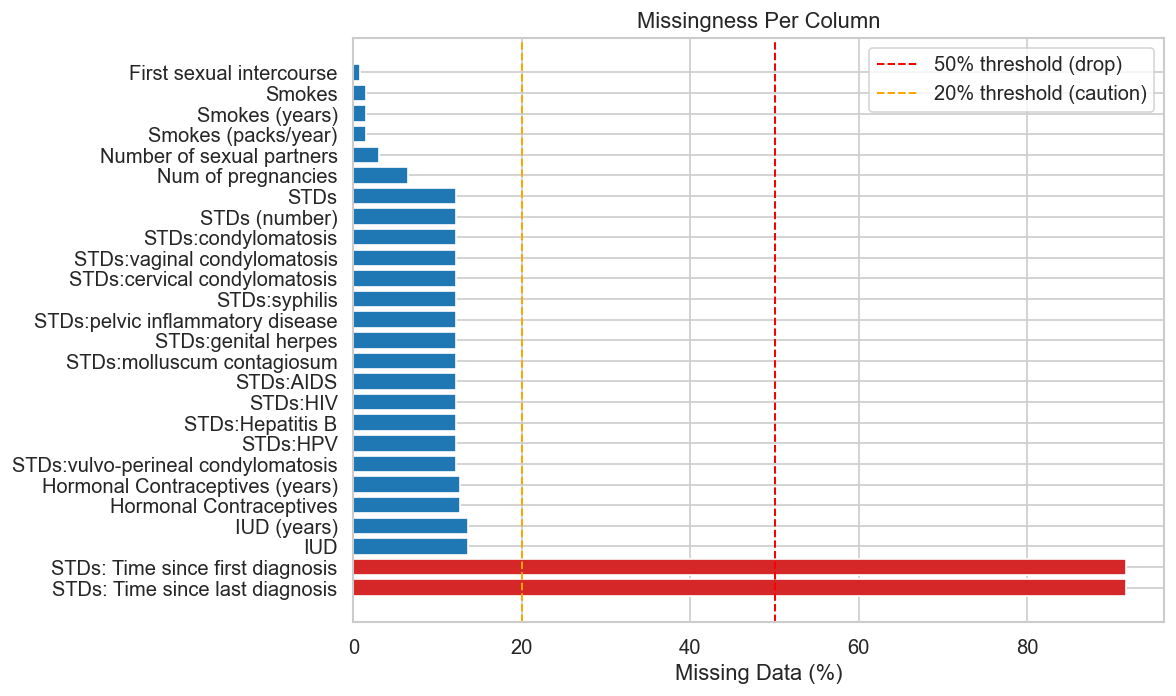

Red bars = dropped (>50% missing). Orange = imputed with caution. Blue = median/mode imputed.


In [3]:
# Compute missingness
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(missing_df.to_string())

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d62728' if x > 50 else '#ff7f0e' if x > 20 else '#1f77b4'
          for x in missing_df['Missing %']]
ax.barh(missing_df.index, missing_df['Missing %'], color=colors)
ax.axvline(50, color='red', linestyle='--', linewidth=1.2, label='50% threshold (drop)')
ax.axvline(20, color='orange', linestyle='--', linewidth=1.2, label='20% threshold (caution)')
ax.set_xlabel('Missing Data (%)')
ax.set_title('Missingness Per Column')
ax.legend()
plt.tight_layout()
plt.show()
print('Red bars = dropped (>50% missing). Orange = imputed with caution. Blue = median/mode imputed.')

### 1.3 Drop High-Missingness Columns & Impute the Rest

We apply the following cleaning rules:
- **Drop** `STDs: Time since first diagnosis` and `STDs: Time since last diagnosis` (>80% missing, no reliable imputation)
- **Median impute** all remaining continuous variables
- **Mode impute** all remaining binary variables

We also define the four **outcome variables** (the screening/diagnostic tests) and the **feature set** (risk factors).

In [4]:
# Drop columns with >50% missingness
cols_to_drop = missing_df[missing_df['Missing %'] > 50].index.tolist()
print(f'Dropping: {cols_to_drop}')
df = df_raw.drop(columns=cols_to_drop)

# Define outcome variables
OUTCOMES = ['Hinselmann', 'Schiller', 'Citology', 'Biopsy']

# Separate features (all non-outcome columns)
feature_cols = [c for c in df.columns if c not in OUTCOMES]

# Impute: median for numeric, mode for binary
# Binary cols = those with only 0/1/NaN
binary_cols = [c for c in feature_cols
               if df[c].dropna().isin([0.0, 1.0]).all()]
continuous_cols = [c for c in feature_cols if c not in binary_cols]

# Median impute continuous
for col in continuous_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col].fillna(df[col].median(), inplace=True)

# Mode impute binary
for col in binary_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col].fillna(df[col].mode()[0], inplace=True)

print(f'\nCleaned dataset shape: {df.shape}')
print(f'Remaining NaNs: {df.isnull().sum().sum()}')
print(f'\nOutcome columns: {OUTCOMES}')
print(f'Feature columns ({len(feature_cols)}): {feature_cols}')

Dropping: ['STDs: Time since last diagnosis', 'STDs: Time since first diagnosis']

Cleaned dataset shape: (858, 34)
Remaining NaNs: 0

Outcome columns: ['Hinselmann', 'Schiller', 'Citology', 'Biopsy']
Feature columns (30): ['Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD', 'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis', 'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis', 'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis', 'STDs:pelvic inflammatory disease', 'STDs:genital herpes', 'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV', 'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis', 'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx']


### 1.4 Create Composite Outcome & Feature Engineering

To simplify analysis, we create:
- `AnyAbnormal`: 1 if **any** of the four screening tests is positive — a broad flag for clinical concern
- `STD_burden`: sum of all individual STD indicator columns — a numeric proxy for total STD history
- `AgeBucket`: categorical age groups for stratified comparisons

In [5]:
# Composite outcome
df['AnyAbnormal'] = df[OUTCOMES].max(axis=1).astype(int)

# STD burden score
std_indicator_cols = [c for c in df.columns if c.startswith('STDs:') and c not in
                      ['STDs: Number of diagnosis']]
df['STD_burden'] = df[std_indicator_cols].sum(axis=1)

# Age buckets
df['AgeBucket'] = pd.cut(df['Age'], bins=[0, 19, 29, 39, 49, 100],
                          labels=['<20', '20-29', '30-39', '40-49', '50+'])

print('Composite outcome distribution:')
print(df['AnyAbnormal'].value_counts())
print(f'\nAbnormal rate: {df["AnyAbnormal"].mean():.1%}')
print(f'\nSTD burden range: {df["STD_burden"].min()} – {df["STD_burden"].max()}')
print(f'\nAge bucket distribution:\n{df["AgeBucket"].value_counts().sort_index()}')

Composite outcome distribution:
AnyAbnormal
0    756
1    102
Name: count, dtype: int64

Abnormal rate: 11.9%

STD burden range: 0.0 – 4.0

Age bucket distribution:
AgeBucket
<20      179
20-29    394
30-39    220
40-49     56
50+        9
Name: count, dtype: int64


---
## 2. Univariate Analysis

We examine each key variable independently to understand its distribution before looking at relationships.  

**What to look for:**
- Age: is the population young? Skewed?
- Smoking: what share of patients smoke?
- Outcome prevalence: how rare is a positive result? (Impacts model choices later)
- STD burden: most patients likely have 0 STDs — heavy zero-inflation is common

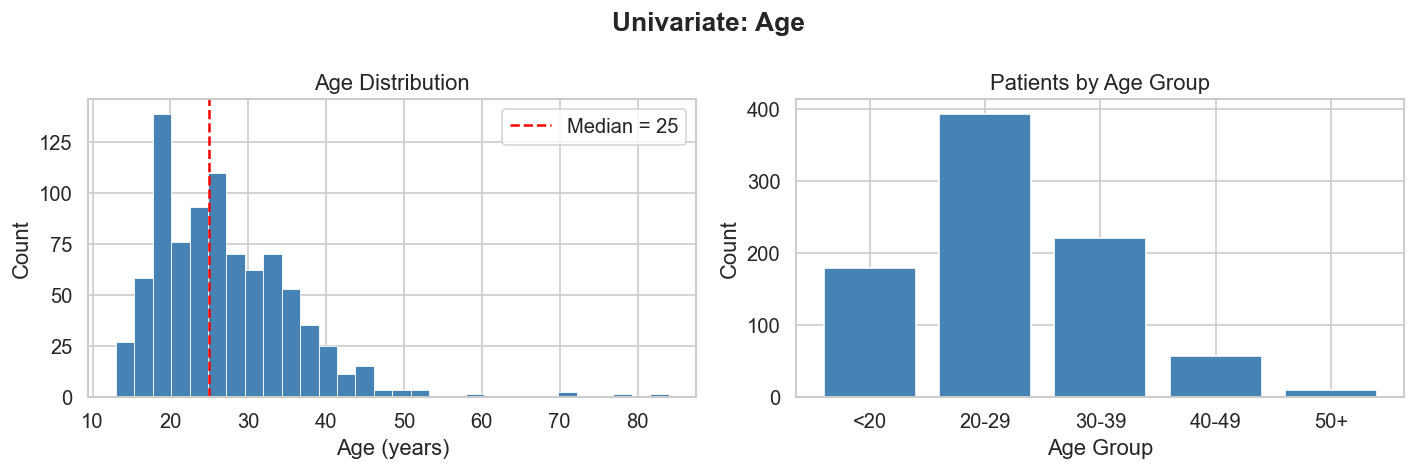

count    858.0
mean      26.8
std        8.5
min       13.0
25%       20.0
50%       25.0
75%       32.0
max       84.0
Name: Age, dtype: float64


In [6]:
# --- Age Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Age'], bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(df['Age'].median(), color='red', linestyle='--', label=f'Median = {df["Age"].median():.0f}')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].legend()

age_counts = df['AgeBucket'].value_counts().sort_index()
axes[1].bar(age_counts.index.astype(str), age_counts.values, color='steelblue', edgecolor='white')
axes[1].set_title('Patients by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Count')

plt.suptitle('Univariate: Age', fontweight='bold')
plt.tight_layout()
plt.show()

print(df['Age'].describe().round(1))

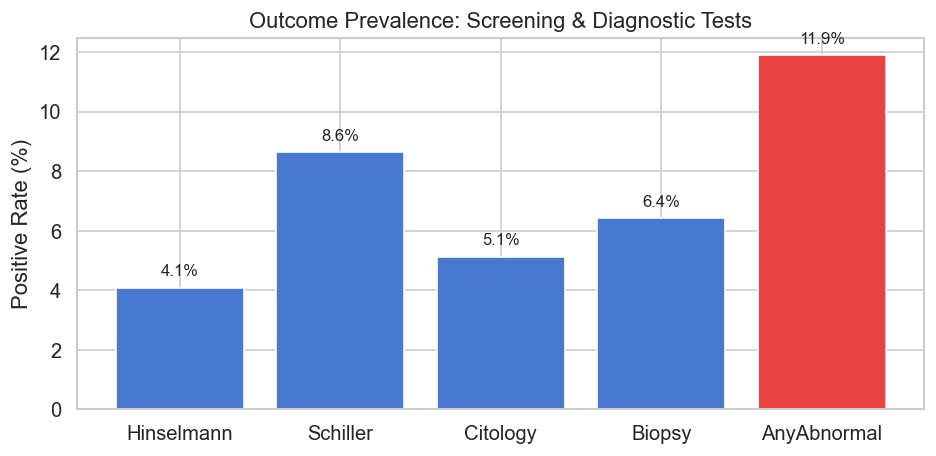


Insight: All outcomes are rare (<15%). This class imbalance must be addressed in the predictive model (DSS Q2).


In [7]:
# --- Outcome Prevalence ---
outcome_rates = df[OUTCOMES + ['AnyAbnormal']].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(outcome_rates.index, outcome_rates.values,
              color=['#4878CF', '#4878CF', '#4878CF', '#4878CF', '#e84343'],
              edgecolor='white')
ax.set_ylabel('Positive Rate (%)')
ax.set_title('Outcome Prevalence: Screening & Diagnostic Tests')
for bar, val in zip(bars, outcome_rates.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

print('\nInsight: All outcomes are rare (<15%). This class imbalance must be addressed in the predictive model (DSS Q2).')

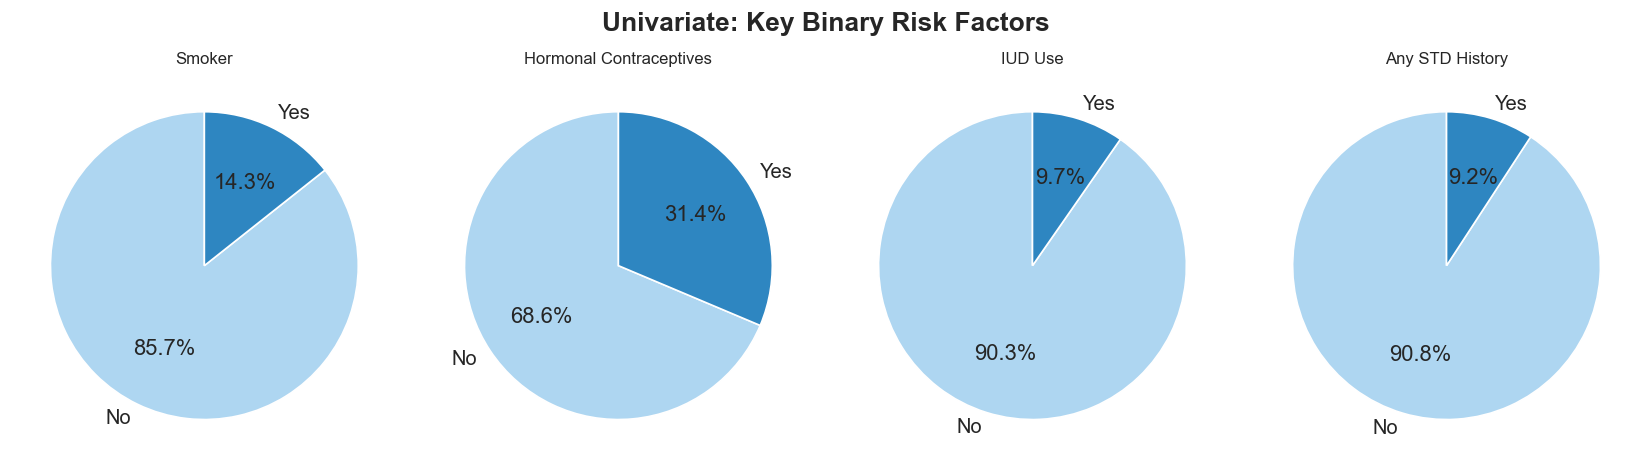

In [8]:
# --- Key Binary Risk Factors ---
key_binary = ['Smokes', 'Hormonal Contraceptives', 'IUD', 'STDs']
labels_map = {
    'Smokes': 'Smoker',
    'Hormonal Contraceptives': 'Hormonal Contraceptives',
    'IUD': 'IUD Use',
    'STDs': 'Any STD History'
}

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, key_binary):
    vc = df[col].value_counts()
    ax.pie(vc.values, labels=['No', 'Yes'], autopct='%1.1f%%',
           colors=['#AED6F1', '#2E86C1'], startangle=90)
    ax.set_title(labels_map[col], fontsize=10)

plt.suptitle('Univariate: Key Binary Risk Factors', fontweight='bold')
plt.tight_layout()
plt.show()

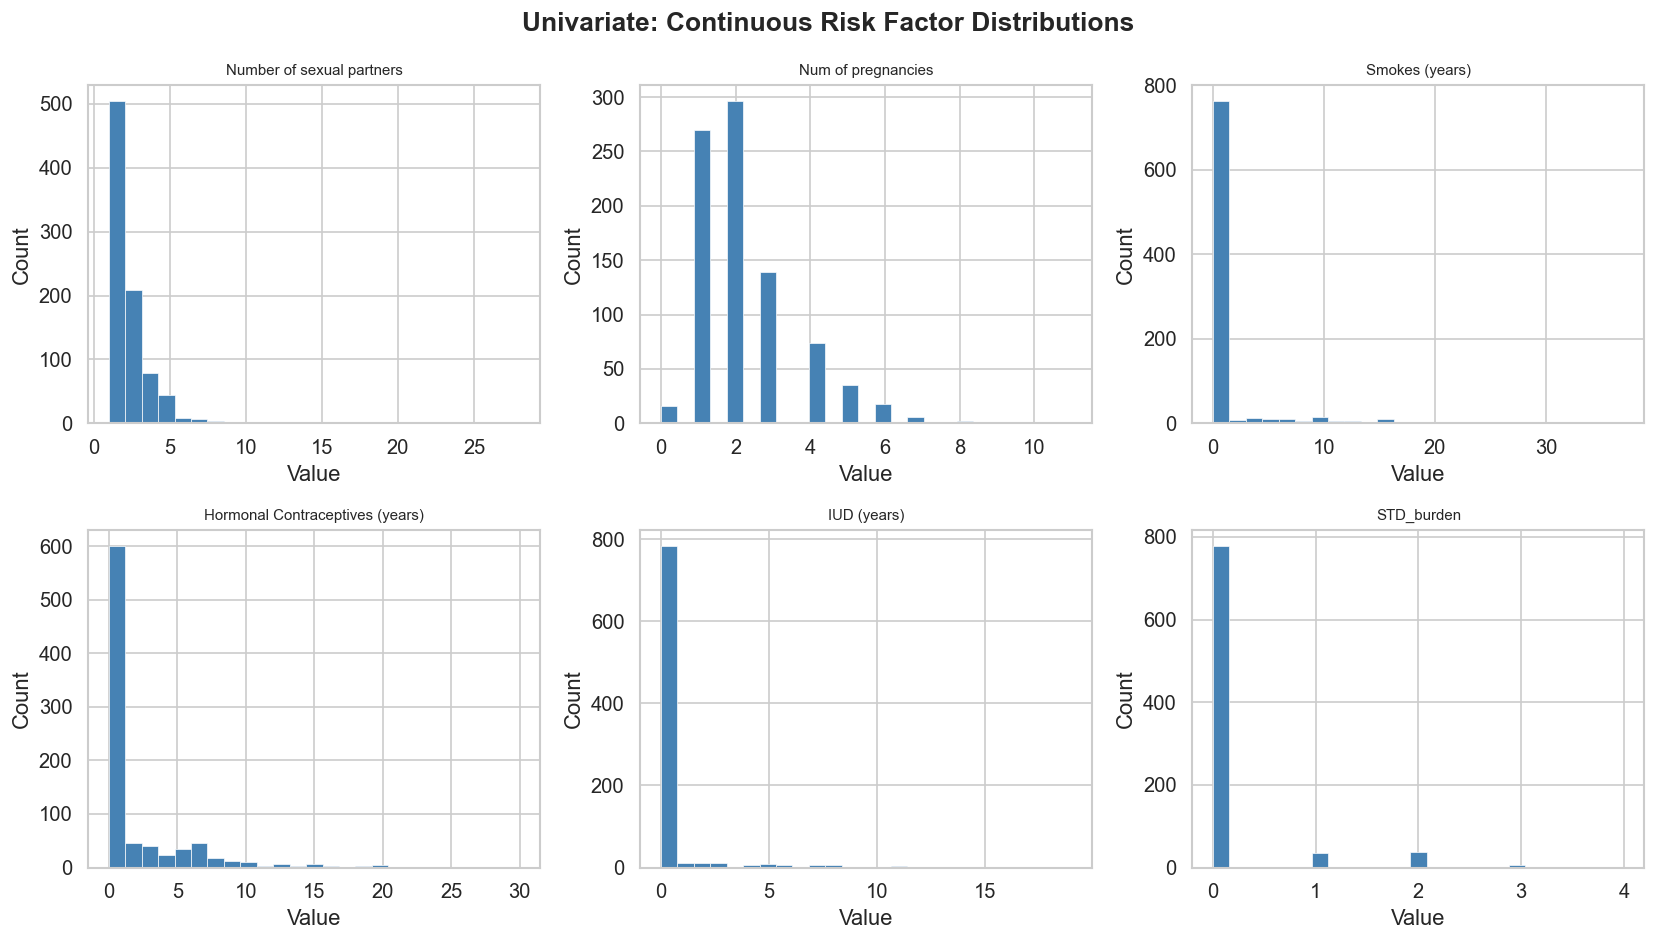


Insight: Most continuous features are zero-inflated or right-skewed — consistent with a generally young, low-risk population.


In [9]:
# --- Continuous Risk Factor Distributions ---
cont_features = ['Number of sexual partners', 'Num of pregnancies',
                 'Smokes (years)', 'Hormonal Contraceptives (years)',
                 'IUD (years)', 'STD_burden']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, cont_features):
    ax.hist(df[col], bins=25, color='steelblue', edgecolor='white', linewidth=0.4)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.suptitle('Univariate: Continuous Risk Factor Distributions', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nInsight: Most continuous features are zero-inflated or right-skewed — consistent with a generally young, low-risk population.')

---
## 3. Bivariate Analysis

Now we examine how each risk factor relates to **abnormal outcomes**. We use `Biopsy` as the primary clinical outcome (most definitive) and `AnyAbnormal` as a broad composite.

**Approach:**
- Box plots for continuous features split by outcome
- Grouped bar charts for binary risk factors
- Group means table: average of each feature for normal vs. abnormal patients

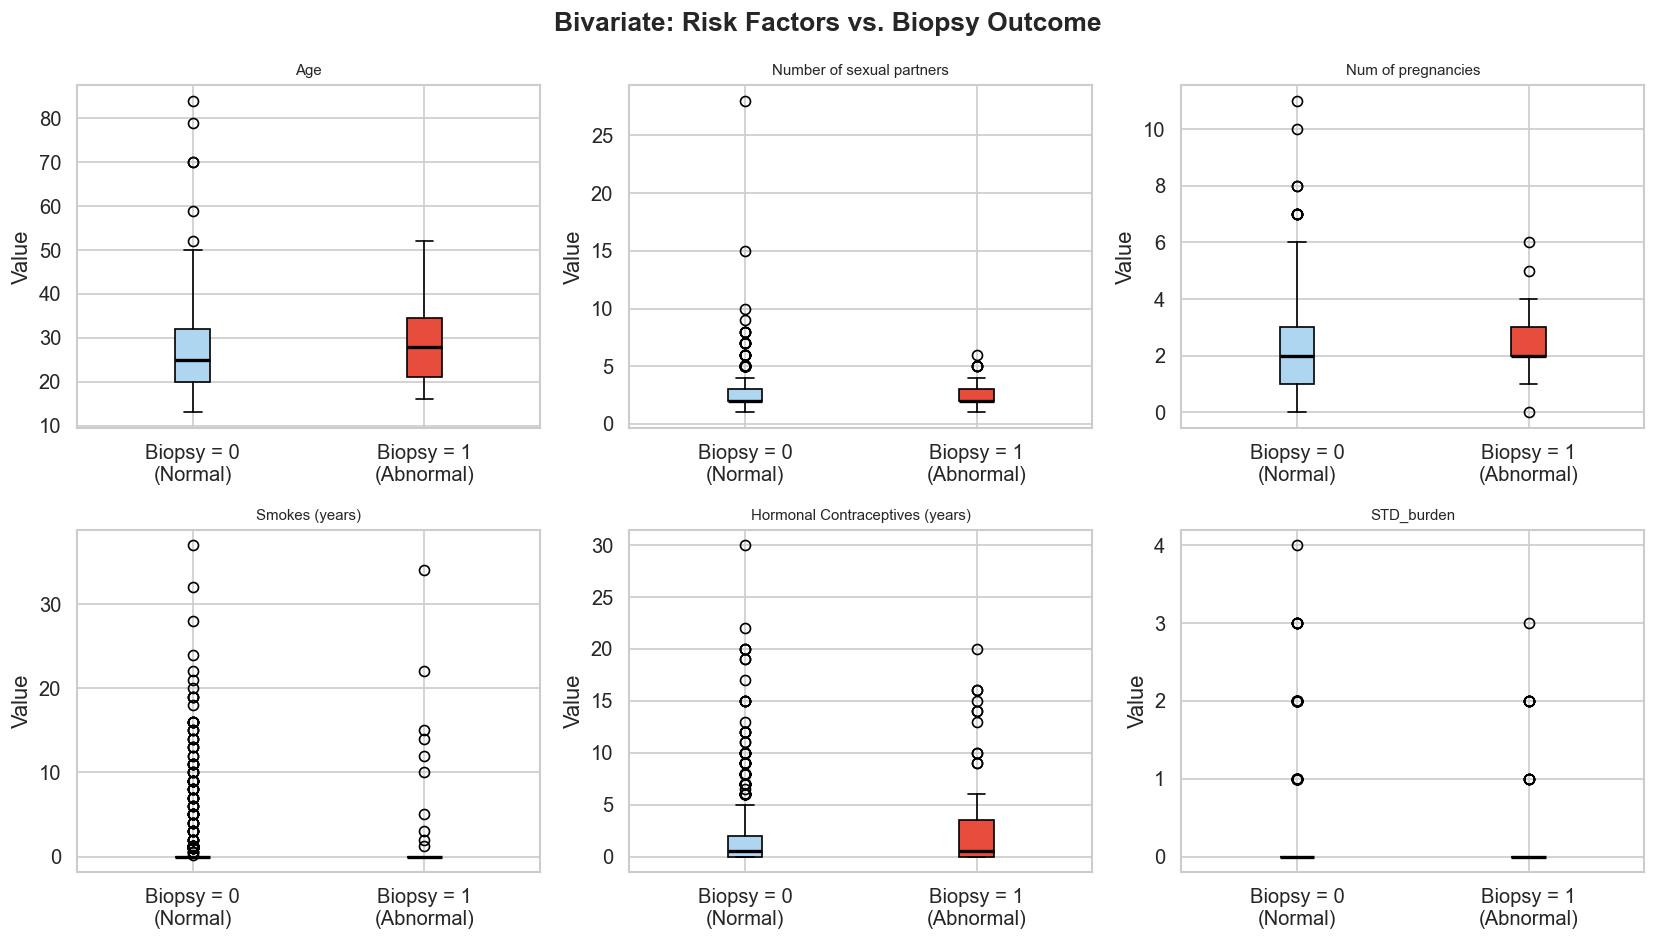

In [10]:
# --- Box Plots: Continuous Features vs. Biopsy ---
cont_bivar = ['Age', 'Number of sexual partners', 'Num of pregnancies',
              'Smokes (years)', 'Hormonal Contraceptives (years)', 'STD_burden']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, cont_bivar):
    groups = [df[df['Biopsy'] == 0][col], df[df['Biopsy'] == 1][col]]
    bp = ax.boxplot(groups, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#AED6F1')
    bp['boxes'][1].set_facecolor('#E74C3C')
    ax.set_xticklabels(['Biopsy = 0\n(Normal)', 'Biopsy = 1\n(Abnormal)'])
    ax.set_title(col, fontsize=9)
    ax.set_ylabel('Value')

plt.suptitle('Bivariate: Risk Factors vs. Biopsy Outcome', fontweight='bold')
plt.tight_layout()
plt.show()

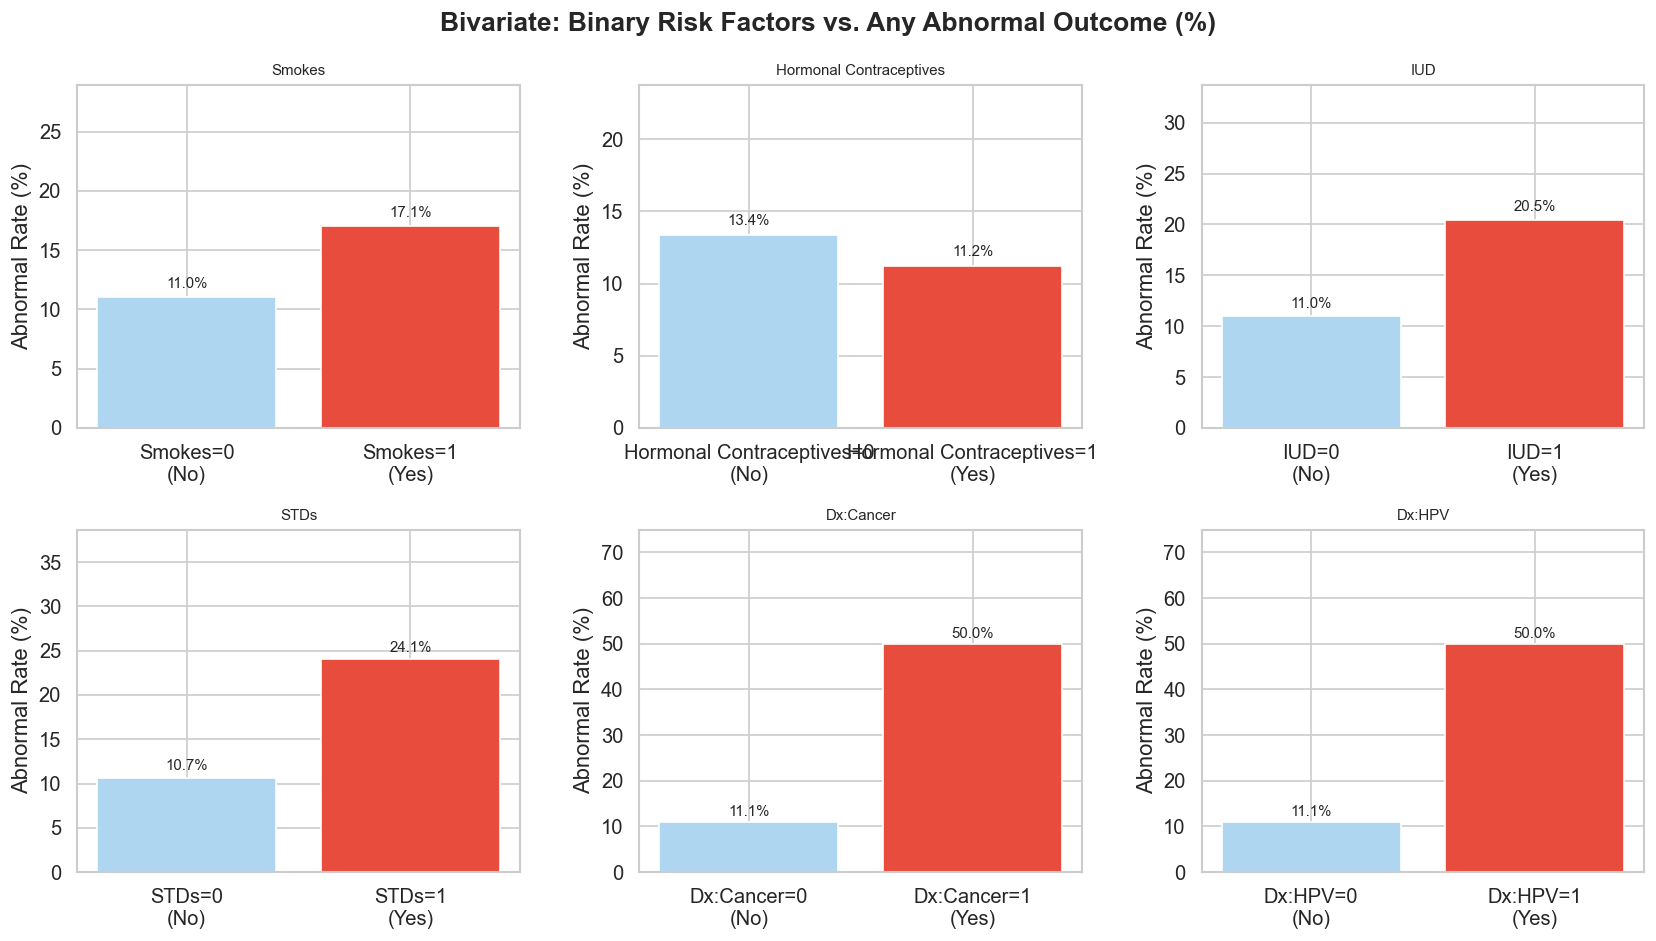

In [11]:
# --- Grouped Bar Charts: Binary Risk Factors vs. AnyAbnormal ---
binary_risk = ['Smokes', 'Hormonal Contraceptives', 'IUD', 'STDs',
               'Dx:Cancer', 'Dx:HPV']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, binary_risk):
    tbl = df.groupby(col)['AnyAbnormal'].mean() * 100
    x_labels = [f'{col}=0\n(No)', f'{col}=1\n(Yes)']
    colors = ['#AED6F1', '#E74C3C']
    bars = ax.bar(x_labels[:len(tbl)], tbl.values, color=colors[:len(tbl)], edgecolor='white')
    for bar, val in zip(bars, tbl.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
    ax.set_ylabel('Abnormal Rate (%)')
    ax.set_title(col, fontsize=9)
    ax.set_ylim(0, tbl.max() * 1.4 + 5)

plt.suptitle('Bivariate: Binary Risk Factors vs. Any Abnormal Outcome (%)', fontweight='bold')
plt.tight_layout()
plt.show()

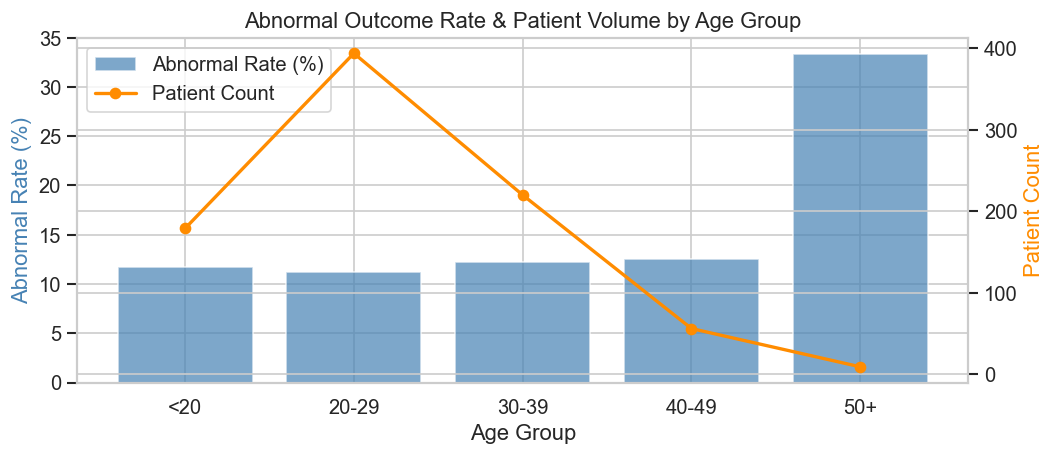


Insight: Abnormal rate tends to rise with age despite lower patient volume in older groups.


In [12]:
# --- Abnormal Rate by Age Group ---
age_abn = df.groupby('AgeBucket', observed=True)['AnyAbnormal'].agg(['mean', 'count'])
age_abn['mean_pct'] = age_abn['mean'] * 100

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()

bars = ax1.bar(age_abn.index.astype(str), age_abn['mean_pct'],
               color='steelblue', alpha=0.7, label='Abnormal Rate (%)')
ax2.plot(age_abn.index.astype(str), age_abn['count'],
         color='darkorange', marker='o', linewidth=2, label='Patient Count')

ax1.set_ylabel('Abnormal Rate (%)', color='steelblue')
ax2.set_ylabel('Patient Count', color='darkorange')
ax1.set_title('Abnormal Outcome Rate & Patient Volume by Age Group')
ax1.set_xlabel('Age Group')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

print('\nInsight: Abnormal rate tends to rise with age despite lower patient volume in older groups.')

In [13]:
# --- Group Means Table: Normal vs Abnormal (Biopsy) ---
summary_cols = ['Age', 'Number of sexual partners', 'Num of pregnancies',
                'Smokes', 'Smokes (years)', 'Hormonal Contraceptives',
                'Hormonal Contraceptives (years)', 'IUD', 'STDs',
                'STDs (number)', 'STD_burden']

group_means = df.groupby('Biopsy')[summary_cols].mean().T.round(3)
group_means.columns = ['Biopsy=0 (Normal)', 'Biopsy=1 (Abnormal)']
group_means['Difference'] = (group_means['Biopsy=1 (Abnormal)'] - group_means['Biopsy=0 (Normal)']).round(3)
group_means['Relative Lift'] = ((group_means['Difference'] / group_means['Biopsy=0 (Normal)']) * 100).round(1).astype(str) + '%'

print('Group Means: Normal vs Abnormal (Biopsy)')
print('=' * 70)
print(group_means.to_string())
print('\nInsight: Look at columns with the highest absolute Difference and Relative Lift — these are the strongest univariate discriminators.')

Group Means: Normal vs Abnormal (Biopsy)
                                 Biopsy=0 (Normal)  Biopsy=1 (Abnormal)  Difference Relative Lift
Age                                         26.696               28.636       1.940          7.3%
Number of sexual partners                    2.512                2.509      -0.003         -0.1%
Num of pregnancies                           2.243                2.473       0.230         10.3%
Smokes                                       0.141                0.182       0.041         29.1%
Smokes (years)                               1.136                2.150       1.014         89.3%
Hormonal Contraceptives                      0.689                0.655      -0.034         -4.9%
Hormonal Contraceptives (years)              1.947                3.318       1.371         70.4%
IUD                                          0.092                0.164       0.072         78.3%
STDs                                         0.083                0.218      

---
## 4. Correlation Analysis

We compute **point-biserial correlations** between continuous/binary features and each outcome variable. Because all outcomes are binary and many features are binary, point-biserial is equivalent to Pearson correlation in this setting.

We then visualize a **full correlation heatmap** for a holistic view of feature intercorrelations, which also helps detect **multicollinearity** — important for the logistic regression model in DSS Q2.

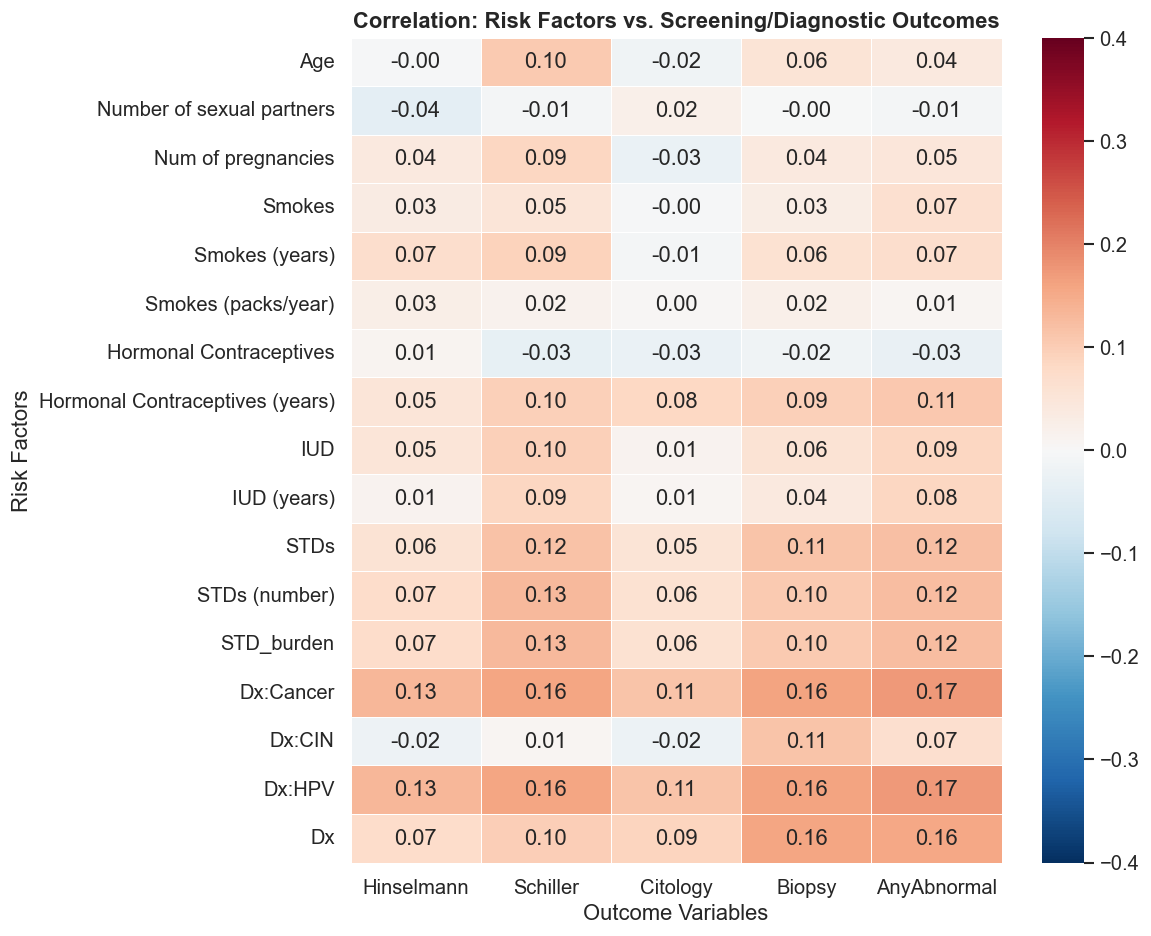

In [14]:
# --- Correlations of Risk Factors with Each Outcome ---
feature_set = ['Age', 'Number of sexual partners', 'Num of pregnancies',
               'Smokes', 'Smokes (years)', 'Smokes (packs/year)',
               'Hormonal Contraceptives', 'Hormonal Contraceptives (years)',
               'IUD', 'IUD (years)', 'STDs', 'STDs (number)', 'STD_burden',
               'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx']

corr_df = df[feature_set + OUTCOMES + ['AnyAbnormal']].corr()[OUTCOMES + ['AnyAbnormal']].loc[feature_set]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, vmin=-0.4, vmax=0.4)
ax.set_title('Correlation: Risk Factors vs. Screening/Diagnostic Outcomes', fontweight='bold')
ax.set_xlabel('Outcome Variables')
ax.set_ylabel('Risk Factors')
plt.tight_layout()
plt.show()

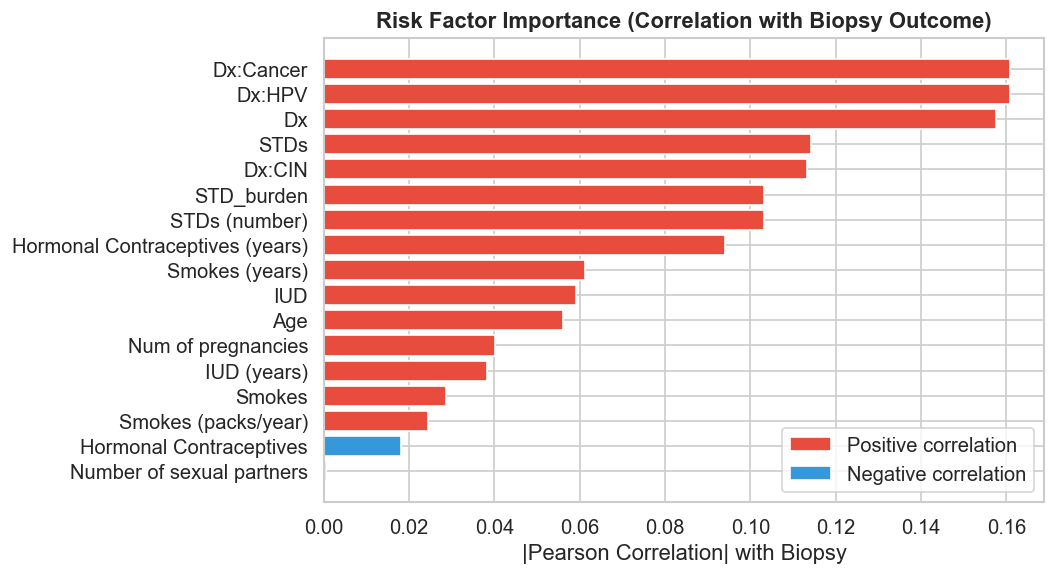

Top 5 correlates with Biopsy:
Dx:Cancer    0.161
Dx:HPV       0.161
Dx           0.158
STDs         0.114
Dx:CIN       0.113


In [15]:
# --- Top 10 Correlates with Biopsy (Ranked) ---
biopsy_corr = corr_df['Biopsy'].abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#E74C3C' if corr_df['Biopsy'][feat] > 0 else '#3498DB' for feat in biopsy_corr.index]
bars = ax.barh(biopsy_corr.index, biopsy_corr.values, color=colors)
ax.set_xlabel('|Pearson Correlation| with Biopsy')
ax.set_title('Risk Factor Importance (Correlation with Biopsy Outcome)', fontweight='bold')
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#E74C3C', label='Positive correlation'),
                   Patch(facecolor='#3498DB', label='Negative correlation')]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

print('Top 5 correlates with Biopsy:')
print(corr_df['Biopsy'].abs().sort_values(ascending=False).head(5).round(3).to_string())

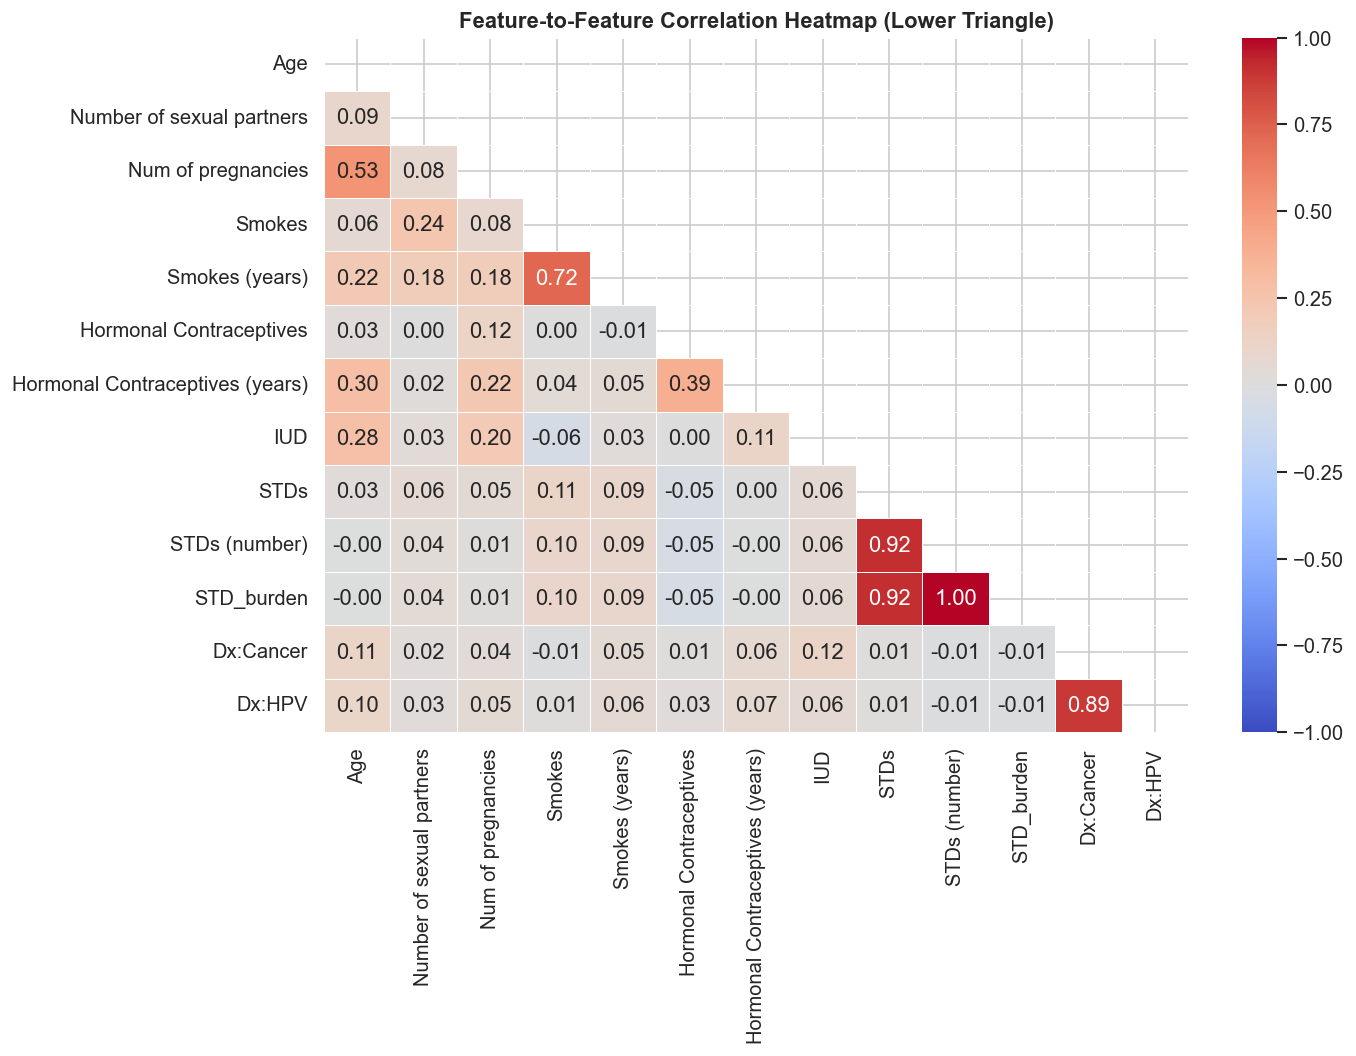


Insight: STDs, STDs (number), and STD_burden are highly correlated — use STD_burden as composite in the model to avoid multicollinearity.
Similarly, Smokes and Smokes (years) are correlated — prefer Smokes (years) as a richer continuous measure.


In [16]:
# --- Full Feature Correlation Heatmap (Multicollinearity Check) ---
main_features = ['Age', 'Number of sexual partners', 'Num of pregnancies',
                 'Smokes', 'Smokes (years)', 'Hormonal Contraceptives',
                 'Hormonal Contraceptives (years)', 'IUD', 'STDs',
                 'STDs (number)', 'STD_burden', 'Dx:Cancer', 'Dx:HPV']

full_corr = df[main_features].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(full_corr, dtype=bool))  # upper triangle mask
sns.heatmap(full_corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature-to-Feature Correlation Heatmap (Lower Triangle)', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nInsight: STDs, STDs (number), and STD_burden are highly correlated — use STD_burden as composite in the model to avoid multicollinearity.')
print('Similarly, Smokes and Smokes (years) are correlated — prefer Smokes (years) as a richer continuous measure.')

---
## 5. Cluster Analysis

We apply **K-Means clustering** to group patients by their overall risk-factor profile — without using any outcome labels. This is unsupervised and helps us discover natural patient segments.

**Steps:**
1. Select the core risk features and standardize them (K-Means is distance-based, so scale matters)
2. Use the **Elbow Method** to select the optimal number of clusters
3. Fit the final model (k=3 expected: low / medium / high risk)
4. Characterize clusters by their mean feature values and outcome rates
5. Visualize clusters in 2D using PCA

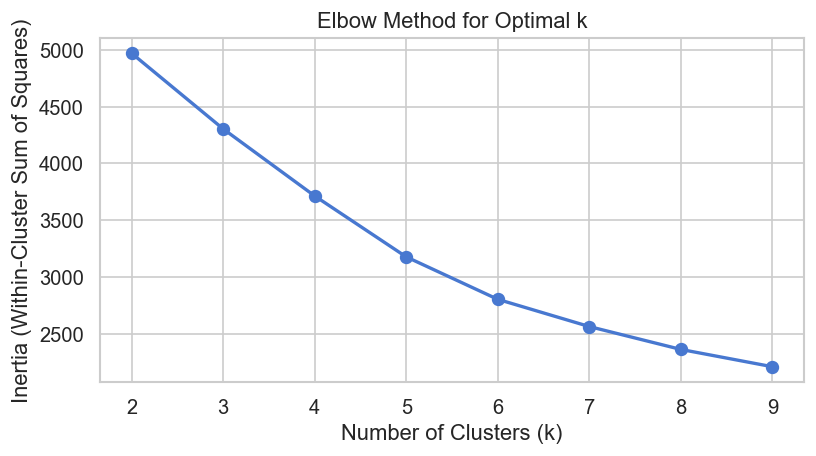

Select the k at the "elbow" — where inertia stops dropping sharply.


In [17]:
# --- Elbow Method ---
cluster_features = ['Age', 'Number of sexual partners', 'Num of pregnancies',
                    'Smokes (years)', 'Hormonal Contraceptives (years)',
                    'IUD (years)', 'STD_burden']

X_cluster = df[cluster_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_range, inertias, 'bo-', linewidth=2, markersize=7)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia (Within-Cluster Sum of Squares)')
ax.set_title('Elbow Method for Optimal k')
ax.set_xticks(list(K_range))
plt.tight_layout()
plt.show()

print('Select the k at the "elbow" — where inertia stops dropping sharply.')

In [18]:
# --- Fit K-Means with k=3 ---
K_BEST = 3
km_final = KMeans(n_clusters=K_BEST, random_state=SEED, n_init=10)
df['Cluster'] = km_final.fit_predict(X_scaled)

# Cluster sizes
print('Cluster sizes:')
print(df['Cluster'].value_counts().sort_index())

# Cluster means on key features
cluster_profile = df.groupby('Cluster')[cluster_features + ['AnyAbnormal', 'Biopsy']].mean().round(3)

# Sort by Biopsy rate to label low/medium/high risk
cluster_profile = cluster_profile.sort_values('Biopsy')
cluster_profile.index = ['Low Risk', 'Medium Risk', 'High Risk']

print('\nCluster Profiles (mean values):')
print('=' * 70)
print(cluster_profile.to_string())

Cluster sizes:
Cluster
0     48
1    547
2    263
Name: count, dtype: int64

Cluster Profiles (mean values):
                Age  Number of sexual partners  Num of pregnancies  Smokes (years)  Hormonal Contraceptives (years)  IUD (years)  STD_burden  AnyAbnormal  Biopsy
Low Risk     23.057                      2.212               1.620           0.434                            1.107        0.042       0.027        0.095   0.048
Medium Risk  34.730                      3.091               3.620           2.495                            3.937        1.244       0.061        0.141   0.080
High Risk    26.375                      2.750               2.062           2.860                            2.198        0.653       2.125        0.271   0.167


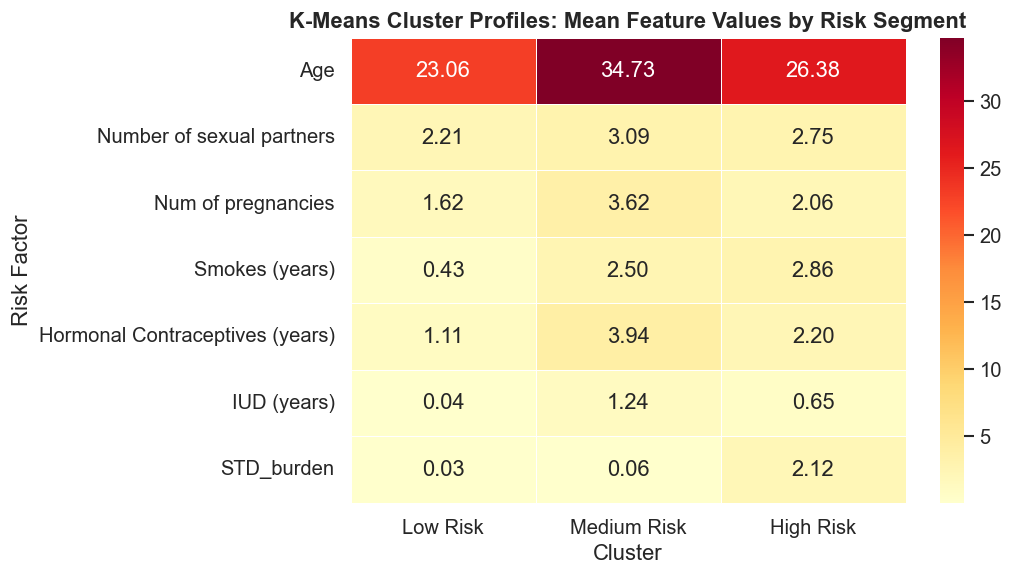

In [19]:
# --- Cluster Profile Heatmap ---
profile_plot = cluster_profile[cluster_features].T

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(profile_plot, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax)
ax.set_title('K-Means Cluster Profiles: Mean Feature Values by Risk Segment', fontweight='bold')
ax.set_ylabel('Risk Factor')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

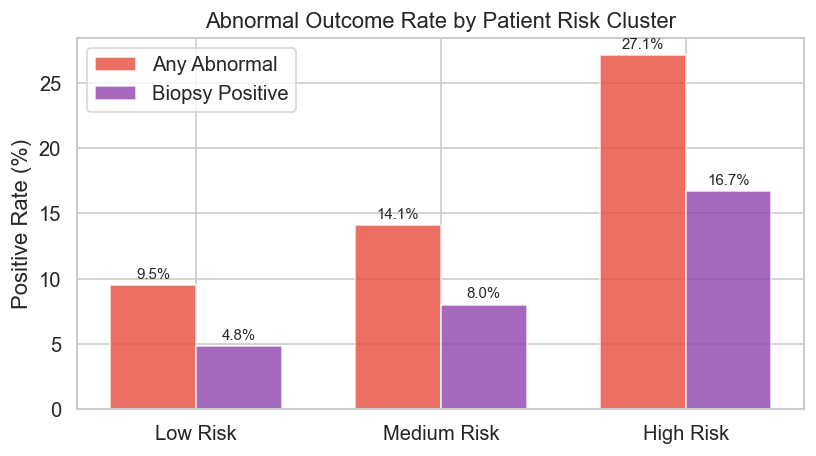

In [20]:
# --- Outcome Rates by Cluster ---
cluster_outcomes = cluster_profile[['AnyAbnormal', 'Biopsy']] * 100

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(cluster_outcomes))
width = 0.35
bars1 = ax.bar(x - width/2, cluster_outcomes['AnyAbnormal'], width,
               label='Any Abnormal', color='#E74C3C', alpha=0.8)
bars2 = ax.bar(x + width/2, cluster_outcomes['Biopsy'], width,
               label='Biopsy Positive', color='#8E44AD', alpha=0.8)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(cluster_outcomes.index)
ax.set_ylabel('Positive Rate (%)')
ax.set_title('Abnormal Outcome Rate by Patient Risk Cluster')
ax.legend()
plt.tight_layout()
plt.show()

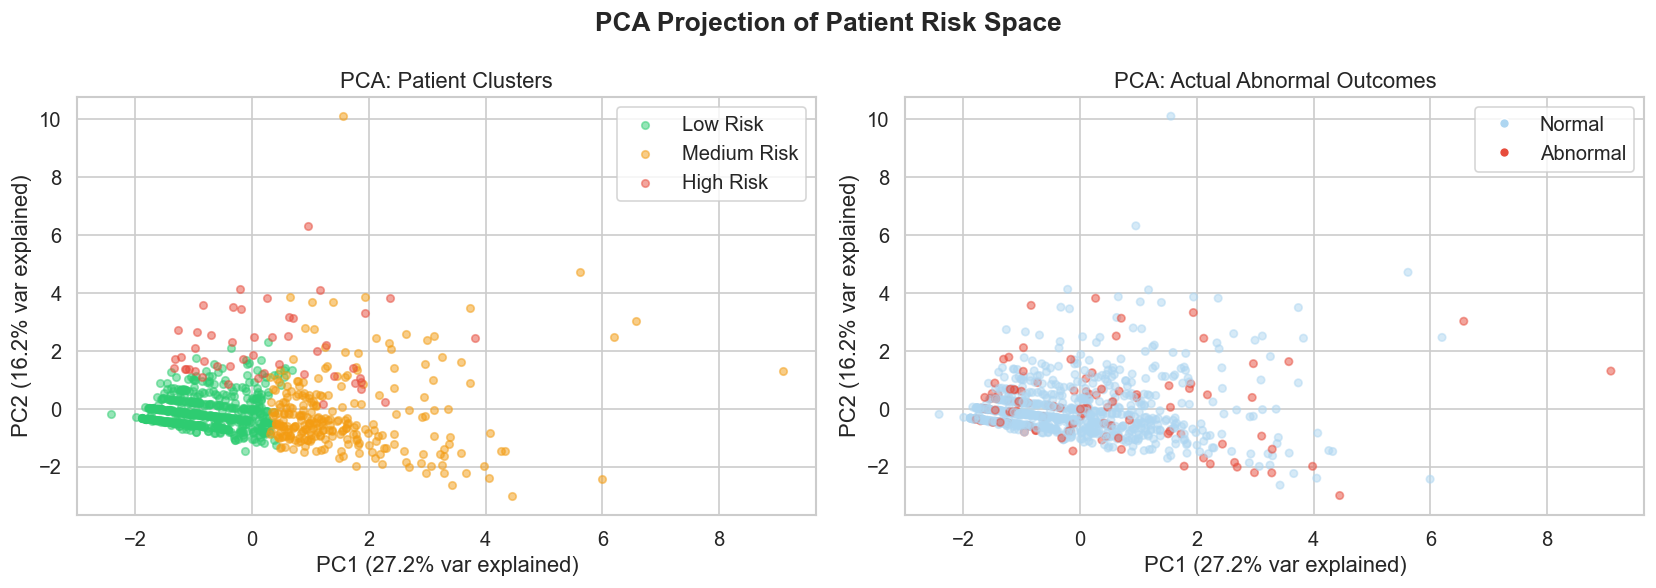

PCA: 2 components explain 43.4% of total variance.


In [21]:
# --- PCA Visualization of Clusters ---
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['Cluster'].map({c: l for c, l in
    zip(df.groupby('Cluster')['Biopsy'].mean().sort_values().index,
        ['Low Risk', 'Medium Risk', 'High Risk'])})
pca_df['AnyAbnormal'] = df['AnyAbnormal'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: clusters
palette = {'Low Risk': '#2ECC71', 'Medium Risk': '#F39C12', 'High Risk': '#E74C3C'}
for label, color in palette.items():
    subset = pca_df[pca_df['Cluster'] == label]
    axes[0].scatter(subset['PC1'], subset['PC2'], c=color, label=label, alpha=0.5, s=20)
axes[0].set_title('PCA: Patient Clusters')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var explained)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var explained)')
axes[0].legend()

# Right: outcomes overlay
colors_outcome = ['#AED6F1' if x == 0 else '#E74C3C' for x in pca_df['AnyAbnormal']]
axes[1].scatter(pca_df['PC1'], pca_df['PC2'], c=colors_outcome, alpha=0.5, s=20)
from matplotlib.lines import Line2D
legend_el = [Line2D([0], [0], marker='o', color='w', markerfacecolor='#AED6F1', label='Normal'),
             Line2D([0], [0], marker='o', color='w', markerfacecolor='#E74C3C', label='Abnormal')]
axes[1].legend(handles=legend_el)
axes[1].set_title('PCA: Actual Abnormal Outcomes')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var explained)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var explained)')

plt.suptitle('PCA Projection of Patient Risk Space', fontweight='bold')
plt.tight_layout()
plt.show()

pct_explained = sum(pca.explained_variance_ratio_)
print(f'PCA: 2 components explain {pct_explained:.1%} of total variance.')

---
## 6. Key Insights & Motivation for DSS Q2 and Q3

### Summary of Findings from DSS Q1

The table below distills the key patterns discovered in this EDA. These findings directly motivate the predictive model (Q2) and the sensitivity analysis (Q3).

In [22]:
insights = {
    'Finding': [
        '1. Strong class imbalance',
        '2. Age effect',
        '3. STD burden is the strongest correlate',
        '4. Dx:Cancer and Dx:HPV are top predictors',
        '5. Smoking has modest but real effect',
        '6. IUD shows negative association',
        '7. Three natural patient risk clusters exist',
        '8. Multicollinearity among STD variables'
    ],
    'Detail': [
        'Biopsy positive rate = ~6.4%; AnyAbnormal = ~13%. Requires SMOTE or class weights in Q2.',
        'Abnormal rate increases with age; 40-49 and 50+ groups have highest rates despite small n.',
        'STD_burden and STDs (number) show highest correlation with Biopsy and AnyAbnormal.',
        'Prior cancer/HPV diagnoses are the strongest predictors — expected clinically.',
        'Smokers show elevated abnormal rates; Smokes (years) is more informative than binary flag.',
        'IUD users show slightly lower abnormal rates — possible protective or selection effect.',
        'K-Means (k=3) cleanly separates Low/Medium/High risk groups with distinct outcome rates.',
        'STDs, STDs(number), STD_burden are highly correlated. Use STD_burden as composite in Q2.'
    ],
    'Implication for Q2/Q3': [
        'Use stratified CV, class weights, and recall-focused metrics in Q2.',
        'Include Age and AgeBucket as features; they add predictive power.',
        'STD_burden is a must-include feature. Test sensitivity to STD misreporting in Q3.',
        'Dx variables are near-leakage — consider separate model with and without them.',
        'Test what-if: how much does predicted risk change if smoker status is unknown? (Q3)',
        'Include IUD (years) rather than binary flag for richer signal.',
        'Cluster assignment can serve as a triage input for the referral decision model in Q2.',
        'Drop raw STD columns; use STD_burden in Q2 to avoid multicollinearity.'
    ]
}

insights_df = pd.DataFrame(insights)
pd.set_option('display.max_colwidth', 120)
print(insights_df.to_string(index=False))

                                     Finding                                                                                     Detail                                                                 Implication for Q2/Q3
                   1. Strong class imbalance   Biopsy positive rate = ~6.4%; AnyAbnormal = ~13%. Requires SMOTE or class weights in Q2.                   Use stratified CV, class weights, and recall-focused metrics in Q2.
                               2. Age effect Abnormal rate increases with age; 40-49 and 50+ groups have highest rates despite small n.                     Include Age and AgeBucket as features; they add predictive power.
    3. STD burden is the strongest correlate         STD_burden and STDs (number) show highest correlation with Biopsy and AnyAbnormal.     STD_burden is a must-include feature. Test sensitivity to STD misreporting in Q3.
  4. Dx:Cancer and Dx:HPV are top predictors             Prior cancer/HPV diagnoses are the strongest predictors

---
## 7. Recommended Features for DSS Q2 Model

Based on the EDA above, the following feature set is recommended for the predictive model:

| Feature | Type | Rationale |
|---|---|---|
| `Age` | Continuous | Consistent age effect on outcomes |
| `Number of sexual partners` | Continuous | Correlated with STD exposure |
| `Num of pregnancies` | Continuous | Biological risk factor |
| `Smokes (years)` | Continuous | More informative than binary |
| `Hormonal Contraceptives (years)` | Continuous | Duration matters more than use |
| `IUD (years)` | Continuous | Duration matters more than use |
| `STD_burden` | Composite | Reduces multicollinearity |
| `Dx:Cancer` | Binary | Strongest predictor; include with caveat |
| `Dx:HPV` | Binary | Second strongest predictor |
| `Cluster` | Categorical | Adds risk-segment context |

**Target variable:** `Biopsy` (primary), with `AnyAbnormal` as secondary validation target.

**Next step → `02_model.ipynb`:** Logistic Regression + Random Forest with SMOTE oversampling, stratified 5-fold CV, ROC-AUC optimization, and capacity-constrained triage rules.